# Pokemon DataSet Analysis

#### El objetivo de este trabajo es realizar un análisis exploratorio de datos a un DataSet completo sobre la información de los pokemons existentes hasta la séptima generación. Para comprender bien las características de los pokemons, se analizarán gran parte de los features que nos entrega el DataSet, esto con el proposito de determinar si dichas características definen, de manera general, el poder que posee cada pokemon.


#### El DataSet se compone de las siguientes características para más de 800 pokemons
- **name:** Nombre en inglés
- **japanese_name:** Nombre original en japonés
- **pokedex_number:** Número de pokemon en la pokedex
- **percentage_male:** Porcentaje de la especie que es masculina (nula si no tiene género)
- **type1:** Tipo principal del pokemon
- **type2:** Tipo secundario del pokemon
- **classification:** Especie descriptiva oficial del pokemon según la pokedex Sun/Moon
- **height_m:** Altura del pokemon en metros
- **weight_kg:** Peso del pokemon en kilogramos
- **capture_rate:** Ratio de captura del pokemon
- **base_egg_steps:** Número de pasos requerido para incubar un huevo
- **abilities:** Lista de habilidades que el pokemon puede tener
- **experience_growth:** Crecimiento de experimencia del pokemon
- **base_happiness:** Felicidad base del pokemon
- **against_?:** Dieciocho características que denotan la cantidad de daño recibido ante un ataque de un tipo determinado
- **hp:** Vida base del pokemon
- **attack:** Daño base del pokemon
- **defense:** Defensa base del pokemon
- **sp_attack:** Ataque especial base del pokemon
- **sp_defense:** Defensa especial base del pokemon
- **speed:** Velocidad base del pokemon
- **base_total:** Suma de las estadísticas básicas
- **generation:** Generación en la que fue introducido el pokemon
- **is_legendary:** Denota si el pokemon es legendario

In [25]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pywaffle as Waffle
import squarify
import ast
import networkx as nx

In [26]:
PokemonSet = pd.read_csv('pokemon.csv', index_col=0)

PokemonSet

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
abilities,,,,,,,,,,,,,,,,,,,,,
"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,88.1,1,65,65,45,grass,poison,6.9,1,0
"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,88.1,2,80,80,60,grass,poison,13.0,1,0
"['Overgrow', 'Chlorophyll']",1.00,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,...,88.1,3,122,120,80,grass,poison,100.0,1,0
"['Blaze', 'Solar Power']",0.50,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
"['Blaze', 'Solar Power']",0.50,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,...,88.1,5,80,65,80,fire,NaN,19.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
['Beast Boost'],0.25,1.0,0.5,2.0,0.5,1.0,2.0,0.5,1.0,0.25,...,NaN,797,107,101,61,steel,flying,999.9,7,1
['Beast Boost'],1.00,1.0,0.5,0.5,0.5,2.0,4.0,1.0,1.0,0.25,...,NaN,798,59,31,109,grass,steel,0.1,7,1
['Beast Boost'],2.00,0.5,2.0,0.5,4.0,2.0,0.5,1.0,0.5,0.50,...,NaN,799,97,53,43,dark,dragon,888.0,7,1


# Verificación de complitud de data
**Nos aseguramos de que el dataset sea completo. En el caso de haber características con alta cantidad de NaN, nos debemos de asegurar de tenerlo en consideración para balancear nuestras fuentes de información y no asumir ideas erronéas con bases de datos incompletas.**

Del resultado observamos que la mayoría de características están completas. La falta de datos en *Percentage_male* corresponde a pokemones que no tienen género asignado, mientras que la falta en *type2* corresponden a pokemones de tipo único. Por otra parte observamos que hay en el conjunto 20 pokemones a los que no se les conoce su peso, y 20 a los que no se le conoce su altura.

In [27]:
datos_faltantes = PokemonSet.isnull().sum()
datos_faltantes1 = datos_faltantes[datos_faltantes>0]
datos_faltantes1


height_m            20
percentage_male     98
type2              384
weight_kg           20
dtype: int64

In [28]:
sin_altura_peso = PokemonSet[PokemonSet['height_m'].isnull() & PokemonSet['weight_kg'].isnull()]
sin_altura_peso[['name', 'height_m', 'weight_kg']].reset_index(drop=True)

,name,height_m,weight_kg
0,Rattata,NaN,NaN
1,Raticate,NaN,NaN
2,Raichu,NaN,NaN
3,Sandshrew,NaN,NaN
4,Sandslash,NaN,NaN
5,Vulpix,NaN,NaN
6,Ninetales,NaN,NaN
7,Diglett,NaN,NaN
8,Dugtrio,NaN,NaN
9,Meowth,NaN,NaN


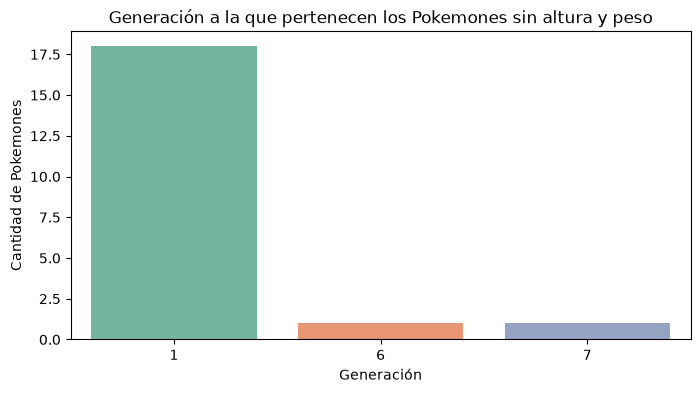

In [29]:
plt.figure(figsize=(8,4))

sns.countplot(data=sin_altura_peso, x='generation', hue='generation', palette='Set2', legend=False)

plt.xlabel('Generación')
plt.ylabel('Cantidad de Pokemones')
plt.title('Generación a la que pertenecen los Pokemones sin altura y peso')

plt.show()

Del presente gráfico se comprueba que 18 de los pokemones a los que les falta información sobre su altura y peso pertenecen a la primera generación, mientras que 1 pertenece a la sexta y 1 a la séptima. A través de esta base de datos no fuimos capaces de demostrar la razón por la que estos pokemones carecen de información sobre sus masas y alturas. Sin embargo, a través de un análisis personal (y ñoño) se observó que los 18 pokemones pertenecientes a la primera generación corresponden a pokemones que poseen variación Alola, mientras que los pokemones de sexta y séptima generación de este grupo también poseen otras variaciones (distintas al Alola). Por lo que se deduce que este DataSet no incluye a las variaciones de pokemones en la pokedex, pero si indetermina estas dos características debido a que existen diferencias entre los originales y sus variaciones.

In [30]:
colores_tipos = {
    'water': '#6991F0',     # Azul
    'normal': '#A8AA79',    # Grisáceo/Beige
    'grass': '#7AC852',     # Verde
    'bug': '#A7B822',       # Verde Amarillento
    'fairy': '#F85887',     # Rosa claro
    'fire': '#EF812E',      # Naranja/Rojo
    'rock': '#B99F38',      # Marrón amarillento
    'electric': '#F6D030',  # Amarillo
    'poison': '#A0429F',    # Morado
    'ground': '#BCA23B',    # Tierra/Arena
    'dark': '#6D5947',      # Marrón oscuro
    'fighting': '#C12F27',  # Rojo oscuro
    'ghost': '#70589A',     # Morado oscuro
    'dragon': '#6B3EE3',    # Índigo/Violeta
    'steel': '#B6B8D0',     # Gris metálico
    'ice': '#9AD7D9',       # Celeste/Hielo
    'psychic': '#FF65D5',   # Rosa brillante
    'flying': '#A991F0'     # Morado claro/Volador
}

# Algo sobre tipos

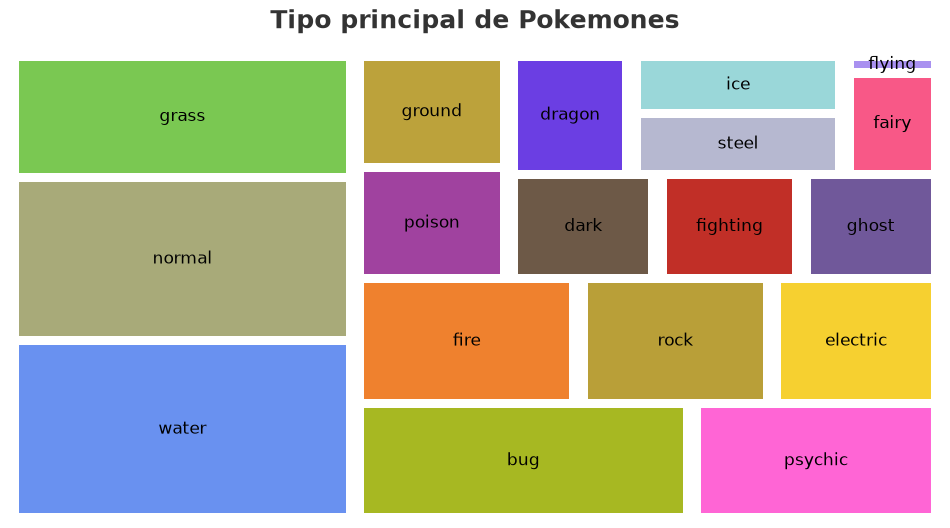

In [31]:
plt.figure(figsize=(12, 6))

type1_values = PokemonSet['type1'].value_counts()

colores = [colores_tipos.get(tipo.lower(), '#CCCCCC') for tipo in type1_values.index]

axis = squarify.plot(
    sizes=type1_values, 
    label=type1_values.index, 
    color=colores, 
    pad=1, 
    text_kwargs={'fontsize': 12}
)

plt.axis("off")
axis.set_title("Tipo principal de Pokemones", fontsize=18, weight='bold', pad=20, color="#333333")

plt.show()

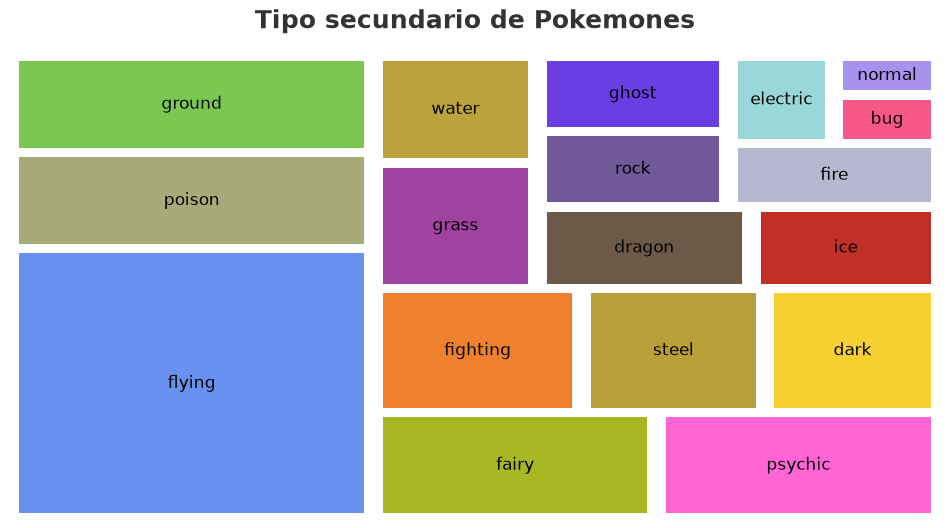

In [32]:
plt.figure(figsize=(12,6))

type2_values = PokemonSet['type2'].value_counts()

colores = [colores_tipos.get(tipo.lower(), '#CCCCCC') for tipo in type1_values.index]

axis = squarify.plot(
    sizes=type2_values, 
    label=type2_values.index, 
    color=colores, 
    pad=1, 
    text_kwargs={'fontsize': 12}
)

plt.axis("off")
axis.set_title("Tipo secundario de Pokemones", fontsize=18, weight='bold', pad=20, color="#333333")

plt.show()

In [33]:
PokemonSet['type_combo'] = np.where(
    PokemonSet['type2'].isna(),
    PokemonSet['type1'],
    PokemonSet['type1'] + '/' + PokemonSet['type2']
)
PokemonSet['type_combo'].value_counts().head(10)

type_combo
water            61
normal           61
grass            37
psychic          35
fire             27
normal/flying    26
electric         26
fighting         22
bug              18
fairy            16
Name: count, dtype: int64

# Algo sobre habilidades

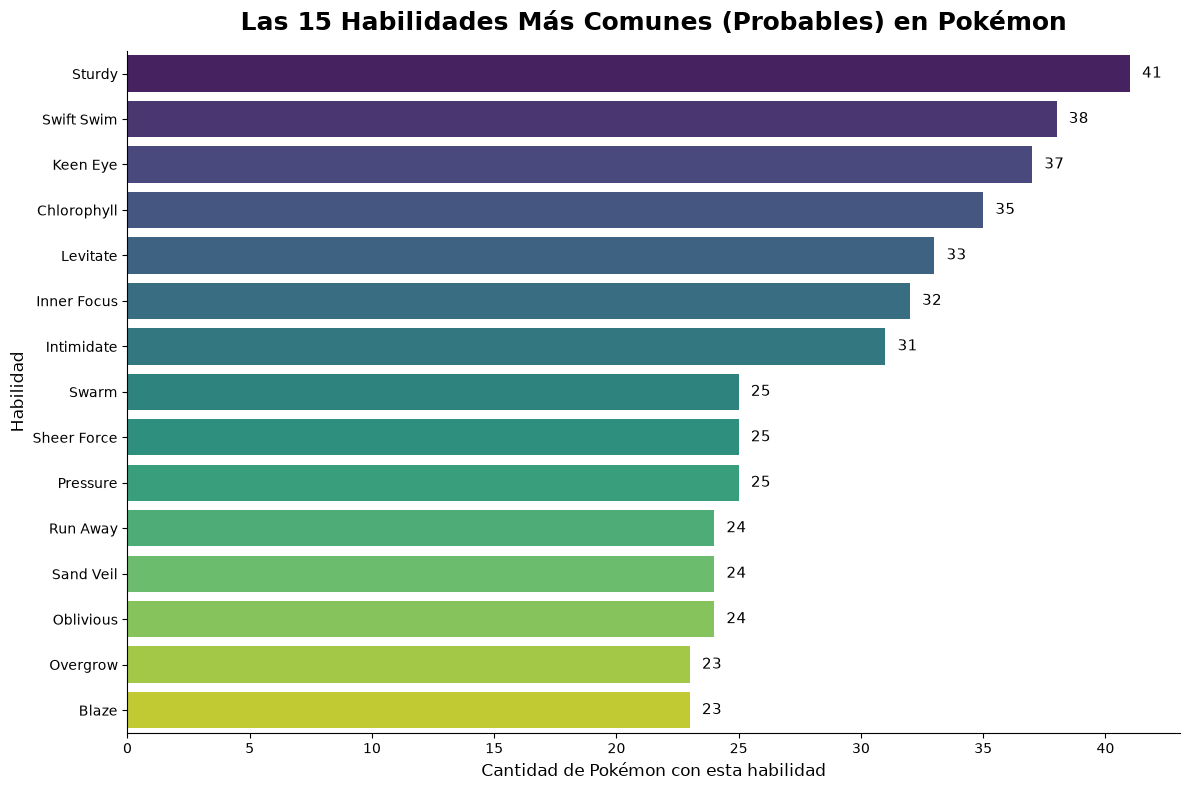

In [34]:
if 'abilities' in PokemonSet.columns:
    abilities_source = PokemonSet['abilities'].to_numpy()
else:
    abilities_source = PokemonSet.index.to_numpy()

def parse_abilities(value):
    if isinstance(value, list):
        return value
    if value is None or pd.isna(value):
        return []
    return ast.literal_eval(value)

PokemonSet['abilities_clean'] = [
    parse_abilities(value) for value in abilities_source
]

# 2. Desempaquetar las listas (una fila por cada habilidad que tenga el Pokémon)
habilidades_separadas = PokemonSet.explode('abilities_clean')

# 3. Contar las frecuencias y obtener el Top 15
top_habilidades = habilidades_separadas['abilities_clean'].value_counts().head(15)

# 4. Crear el gráfico de barras horizontales
plt.figure(figsize=(12, 8))
sns.barplot(x=top_habilidades.values, y=top_habilidades.index, hue=top_habilidades.index, palette='viridis', legend=False)

# Estilos y etiquetas
plt.title("Las 15 Habilidades Más Comunes (Probables) en Pokémon", fontsize=18, weight='bold', pad=15)
plt.xlabel("Cantidad de Pokémon con esta habilidad", fontsize=12)
plt.ylabel("Habilidad", fontsize=12)

# Añadir los números exactos al lado de cada barra
for index, value in enumerate(top_habilidades.values):
    plt.text(value + 0.5, index, str(value), va='center', fontsize=11)

# Eliminar los bordes superior y derecho para un look más limpio
sns.despine()

plt.tight_layout()
plt.show()

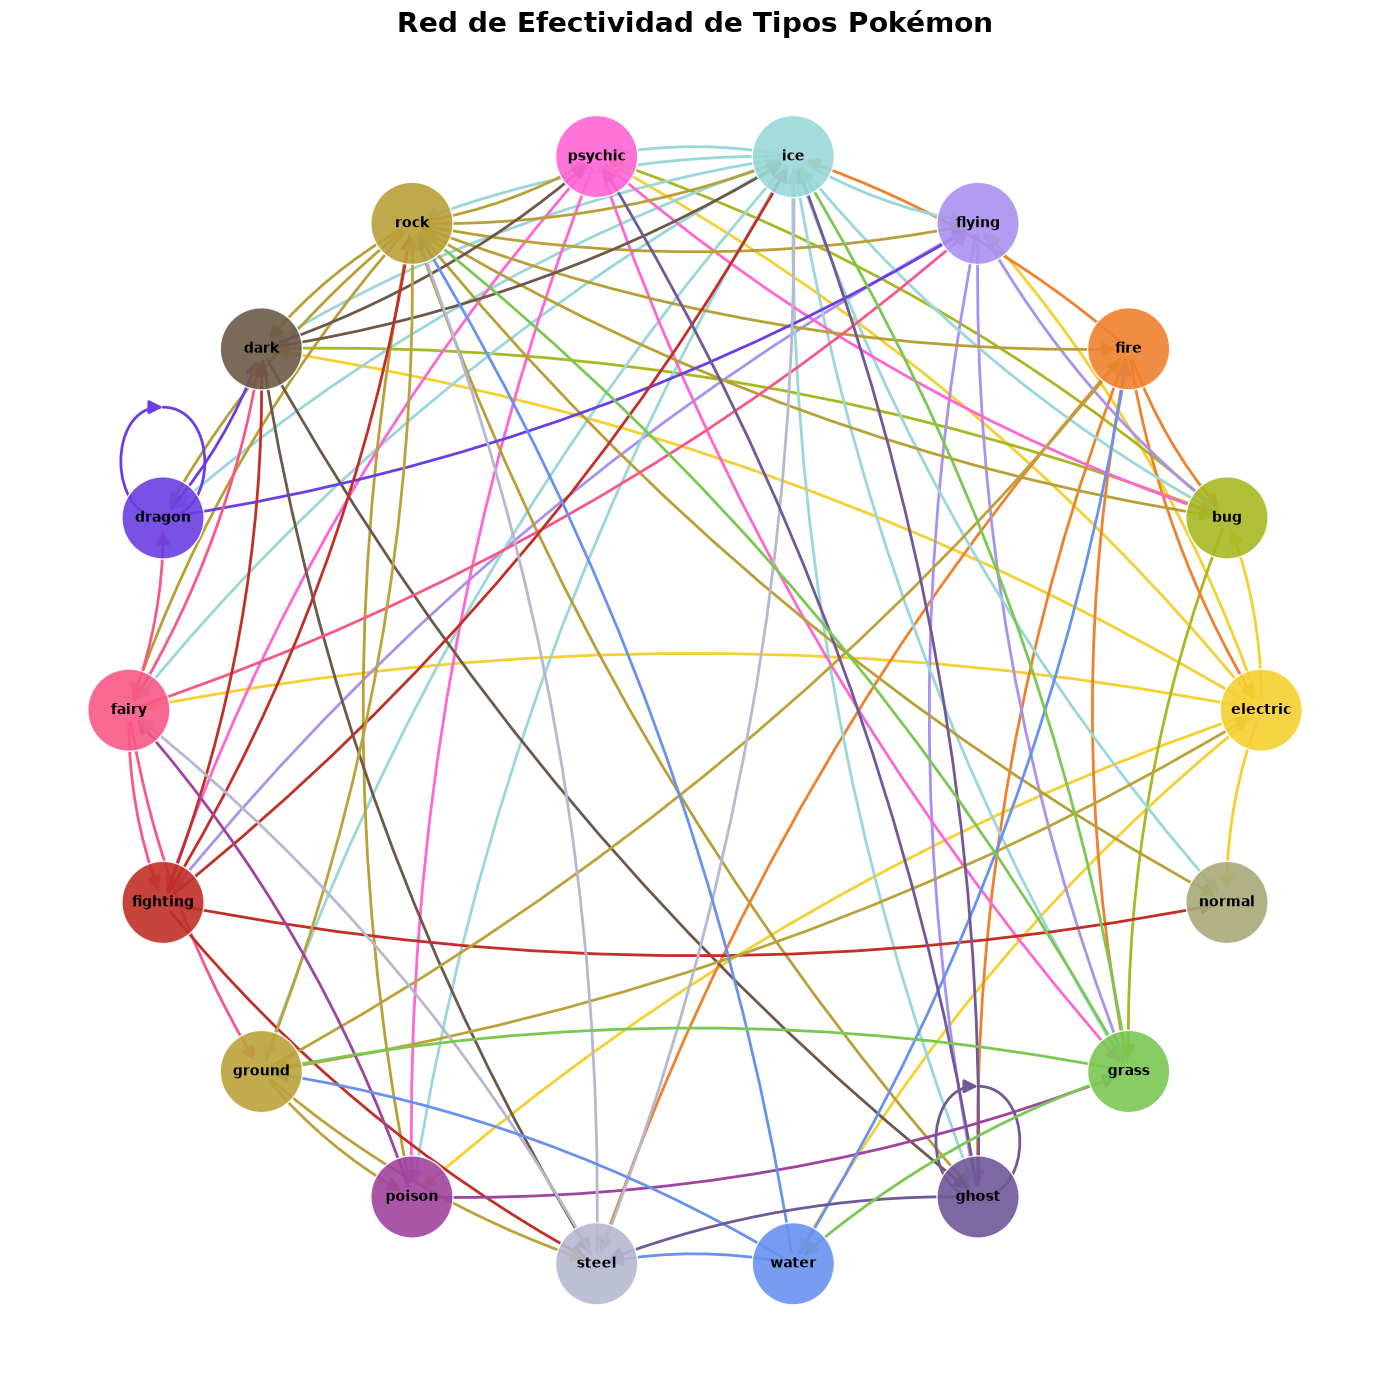

In [35]:
columnas_contra = [col for col in PokemonSet.columns if col.startswith('against_')]
efectividad = PokemonSet.groupby('type1')[columnas_contra].mean()


conexiones = []
for tipo_defensor in efectividad.index:
    for col in columnas_contra:
        tipo_atacante = col.replace('against_', '')
        
        if tipo_atacante == 'fight':
            tipo_atacante = 'fighting'
            
        if efectividad.loc[tipo_defensor, col] > 1.1: 
            conexiones.append((tipo_atacante, tipo_defensor))

G = nx.DiGraph()
G.add_edges_from(conexiones)

colores_nodos = [colores_tipos[nodo] for nodo in G.nodes()]

colores_flechas = [colores_tipos[origen] for origen, destino in G.edges()]

plt.figure(figsize=(14, 14))
posiciones = nx.circular_layout(G)

nx.draw_networkx_nodes(G, posiciones, node_size=3500, node_color=colores_nodos, alpha=0.9, edgecolors='white')
nx.draw_networkx_labels(G, posiciones, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, posiciones, 
                       edgelist=G.edges(), 
                       arrowstyle='-|>', 
                       arrowsize=20, 
                       edge_color=colores_flechas,
                       width=2.0, # ¡Aquí está el cambio clave!
                       connectionstyle='arc3,rad=0.1', 
                       alpha=1) 

plt.title("Red de Efectividad de Tipos Pokémon", fontsize=20, weight='bold')
plt.axis("off")
plt.tight_layout()
plt.show()

# Análisis de Pokemones Legendarios

Los pokemones legendarios se suelen interpretar como pokemones ultra poderosos. De la sección anterior vimos que el rango de poder (base_total) varía desde los 150 hasta los ~800 puntos, por lo que para tener una mejor visualización de los rangos a los que pertenecen los pokemones legendarios, dividimos la investigación en grupos de 100 puntos para los intervalos en los que se encuentran los pokemones que buscamos. De está manera, queremos saber si un pokemon se define como legendario en base a su poder total.

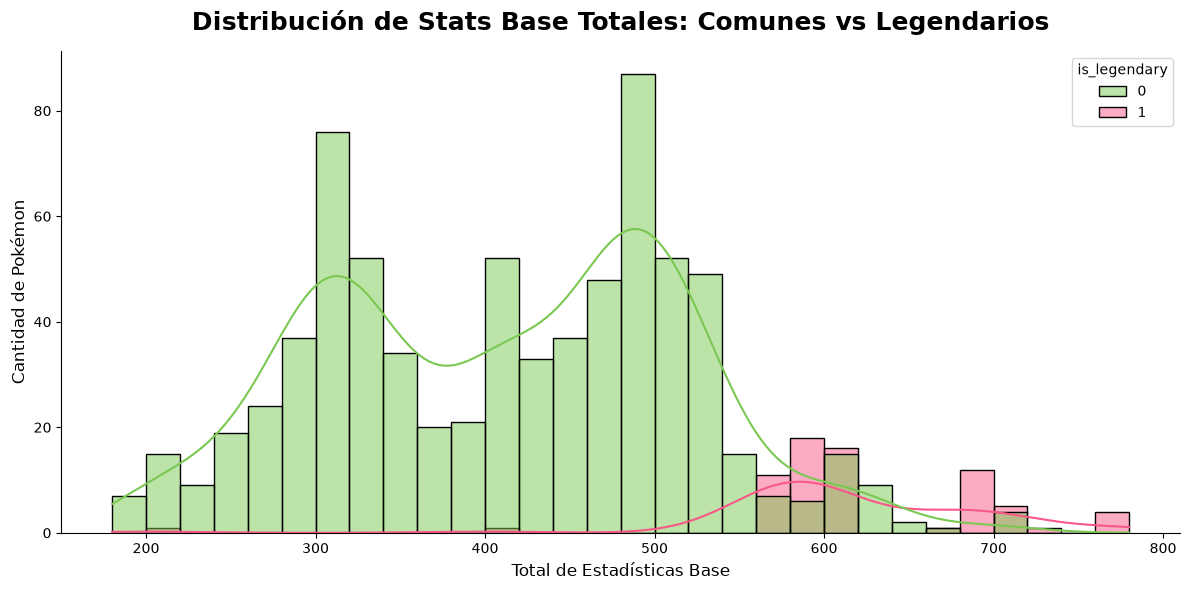

In [36]:
plt.figure(figsize=(12, 6))

# Creamos el histograma para la columna 'base_total'
# hue='is_legendary' separa los colores automáticamente
# kde=True dibuja la línea de tendencia suavizada
sns.histplot(data=PokemonSet, 
             x='base_total', 
             hue='is_legendary', 
             palette={0: '#7AC852', 1: '#F85887'}, # Verde (Comunes) y Rosa (Legendarios)
             kde=True, 
             bins=30, 
             alpha=0.5)

# Estilos y textos
plt.title("Distribución de Stats Base Totales: Comunes vs Legendarios", fontsize=18, weight='bold', pad=15)
plt.xlabel("Total de Estadísticas Base", fontsize=12)
plt.ylabel("Cantidad de Pokémon", fontsize=12)

# Desactivar bordes innecesarios para mayor limpieza
sns.despine()

plt.tight_layout()
plt.show()

In [37]:
min_val = int(np.floor(PokemonSet['base_total'].min() / 50.0) * 50)
max_val = int(np.ceil(PokemonSet['base_total'].max() / 50.0) * 50)
bins = list(range(min_val, max_val + 51, 50))

PokemonSet['rango_poder'] = pd.cut(
    PokemonSet['base_total'],
    bins=bins,
    right=False,
    include_lowest=True
)


distribucion = PokemonSet['rango_poder'].value_counts().sort_index()
distribucion

rango_poder
[150, 200)      7
[200, 250)     32
[250, 300)     73
[300, 350)    146
[350, 400)     57
[400, 450)     97
[450, 500)    161
[500, 550)    111
[550, 600)     47
[600, 650)     42
[650, 700)     14
[700, 750)     10
[750, 800)      4
[800, 850)      0
Name: count, dtype: int64

In [38]:
filtro_legendarios = (
    (PokemonSet['rango_poder'] == pd.Interval(700, 750, closed='left')) |
    (PokemonSet['rango_poder'] == pd.Interval(750, 800, closed='left'))
)

Pokemones_Legendarios = PokemonSet[filtro_legendarios]
Pokemones_Legendarios = Pokemones_Legendarios[['name', 'base_total', 'type_combo', 'is_legendary']].reset_index(drop=True)
Pokemones_Legendarios.sort_values(by='base_total', ascending=False, inplace=True)
Pokemones_Legendarios
#Legend = Pokemones_Legendarios[Pokemones_Legendarios['is_legendary'] == 1].reset_index(drop=True)
#Legend

,name,base_total,type_combo,is_legendary
0,Mewtwo,780,psychic,1
8,Rayquaza,780,dragon/flying,1
6,Kyogre,770,water,1
7,Groudon,770,ground,1
10,Arceus,720,normal,1
12,Zygarde,708,dragon/ground,1
5,Latios,700,dragon/psychic,1
4,Latias,700,dragon/psychic,1
3,Metagross,700,steel/psychic,0
2,Salamence,700,dragon/flying,0


In [39]:
filtro_pseudolegendarios = (
    (PokemonSet['rango_poder'] == pd.Interval(600, 650, closed='left')) |
    (PokemonSet['rango_poder'] == pd.Interval(650, 700, closed='left'))
)

Pokemones_Pseudolegendarios = PokemonSet[filtro_pseudolegendarios]
Pokemones_Pseudolegendarios = Pokemones_Pseudolegendarios[['name', 'base_total', 'type_combo', 'is_legendary']].reset_index(drop=True)
Pokemones_Pseudolegendarios.sort_values(by='base_total', ascending=False, inplace=True)
Pokemones_Pseudolegendarios
#PseudoLegend = Pokemones_Pseudolegendarios[Pokemones_Pseudolegendarios['is_legendary'] == 1].reset_index(drop=True)
#PseudoLegend

,name,base_total,type_combo,is_legendary
16,Ho-Oh,680,fire/flying,1
15,Lugia,680,psychic/flying,1
46,Xerneas,680,fairy,1
48,Hoopa,680,psychic/ghost,1
32,Giratina,680,ghost/dragon,1
39,Reshiram,680,dragon/fire,1
28,Dialga,680,steel/dragon,1
29,Palkia,680,water/dragon,1
40,Zekrom,680,dragon/electric,1
47,Yveltal,680,dark/flying,1


In [40]:
filtro_epicos = (
    (PokemonSet['rango_poder'] == pd.Interval(500, 550, closed='left')) |
    (PokemonSet['rango_poder'] == pd.Interval(550, 600, closed='left'))
)

Pokemones_Epicos = PokemonSet[filtro_epicos]
Pokemones_Epicos = Pokemones_Epicos[['name', 'base_total', 'type_combo', 'is_legendary']].reset_index(drop=True)
Pokemones_Epicos.sort_values(by='base_total', ascending=False, inplace=True)
EpicLegend = Pokemones_Epicos[Pokemones_Epicos['is_legendary'] == 1].reset_index(drop=True)
EpicLegend

,name,base_total,type_combo,is_legendary
0,Articuno,580,ice/flying,1
1,Zapdos,580,electric/flying,1
2,Suicune,580,water,1
3,Regice,580,ice,1
4,Regirock,580,rock,1
5,Entei,580,fire,1
6,Cobalion,580,steel/fighting,1
7,Moltres,580,fire/flying,1
8,Uxie,580,psychic,1
9,Terrakion,580,rock/fighting,1


In [41]:
filtro_odd = (
    (PokemonSet['rango_poder'] == pd.Interval(150, 200, closed='left')) |
    (PokemonSet['rango_poder'] == pd.Interval(200, 250, closed='left')) |
    (PokemonSet['rango_poder'] == pd.Interval(250, 300, closed='left')) |
    (PokemonSet['rango_poder'] == pd.Interval(300, 350, closed='left')) |
    (PokemonSet['rango_poder'] == pd.Interval(350, 400, closed='left')) |
    (PokemonSet['rango_poder'] == pd.Interval(400, 450, closed='left')) |
    (PokemonSet['rango_poder'] == pd.Interval(450, 500, closed='left')) 
    )

Pokemones_Odds = PokemonSet[filtro_odd]
Pokemones_Odds = Pokemones_Odds[['name', 'base_total', 'type_combo', 'is_legendary']].reset_index(drop=True)
Pokemones_Odds.sort_values(by='base_total', ascending=False, inplace=True)
OddLegend = Pokemones_Odds[Pokemones_Odds['is_legendary'] == 1].reset_index(drop=True)
OddLegend

,name,base_total,type_combo,is_legendary
0,Cosmoem,400,psychic,1
1,Cosmog,200,psychic,1


In [42]:
Poder_Promedio = PokemonSet['base_total'].mean()
print(f'El poder promedio de los pokemones es: {Poder_Promedio}')

El poder promedio de los pokemones es: 428.3770287141074


En el rango de pokemones legendarios con poder>700, encontramos 10 pokemones donde 4 lideran este rango:
- Mewtwo:    780 puntos
- Rayquaza:  780 puntos
- Kyogre:    770 puntos
- Groudon:   770 puntos

En este grupo también están presentes 4 pokemones no legendarios, cuyas estadísticas corresponden a las de sus mega evoluciones. De no considerar las mega evoluciones, es justo decir que el rango >700 pertenece exclusivamente a pokemones legendarios.

Por otra parte, en el rango 600<poder<700 se observa que esta principalmente gobernado por pokemones legendarios (29), y cuenta también con la presencia de varios pokemones no legendarios con mega evolución o con variaciones más poderosas (Greninja y Wishiwashi). Sin embargo, en este grupo se presencia además que hay pokemones que sin mega evolución o modificaciones se ganan un lugar en este rango, este es el caso de:
- Slaking (común):               670 puntos
- Dragonite (pseudo-legendario): 600 puntos
- Hydreigon (pseudo-legendario): 600 puntos
- Goodra (pseudo-legendario):    600 puntos
- Kommo-o (pseudo-legendario):   600 puntos

En el rango 500<poder<600 se encuentran la gran mayoría de los pokemones con sus estadísticas normales, pero que están más arriba debido a su mega evolución. También hay una gran cantidad de pokemones comúnes, y una cantidad menor de pokemones legendarios (29). Aquí se encuentra la cota inferior de poder de pokemones legendarios, siendo esta 570 puntos.

A pesar de lo mencionado en el párrafo anterior, existen dos pokemones legendarios que se encuentran por debajo de la cota inferior mencionada, estos son:
- Cosmog
- Cosmoem

La razón por la que no se consideran dentro del rango mínimo de pokemones legendarios, es debido a que siguen una línea evolutiva. Cosmog evoluciona a Cosmoem, y Cosmoem evoluciona a Solgaleo o Lunala (ambos con 680 de poder).

### Conclusión sobre legendarios

Aunque es cierto que todos los pokemones legendarios (sin considerar a Cosmog ni a Cosmoem) tiene un poder mayor que el promedio, y que los pokemones más poderosos son legendarios, también es cierto que otros legendarios poseen un poder similar al de pokemones comúnes y/o a sus megaevoluciones, por lo que no sería correcto definir a los pokemones legendarios en base a su poder. La categoría "Legendario" no necesariamente está relacionada a una característica cuantitativa de los pokemones, sino que puede estar relacionada a su historia e influencia sobre el mundo de Pokemon.

# Análisis de Pokemones por Tipo

Una categoría importante para diferenciar a los pokemones es su tipo. Existen 18 tipos elementales principales:
- Acero
- Agua
- Bicho
- Dragón
- Eléctrico
- Fantasma
- Fuego
- Hada 
- Hielo
- Lucha
- Normal
- Planta
- Psíquico
- Roca
- Siniestro
- Tierra
- Veneno
- Volador

Los pokemones pueden ser de un único tipo, o pueden tener una combinación de dos tipos, donde se denomina el tipo principal y el tipo secundario. El propósito de esta sección es observar si los pokemones de un mismo tipo comparten características además de su elemento principal.

In [43]:
Pokemones_Acero = PokemonSet[PokemonSet['type1']=='steel']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'steel'])} pokemones de tipo acero')
Pokemones_Agua = PokemonSet[PokemonSet['type1']=='water']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'water'])} pokemones de tipo agua')
Pokemones_Bicho = PokemonSet[PokemonSet['type1']=='bug']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'bug'])} pokemones de tipo bicho')
Pokemones_Dragón = PokemonSet[PokemonSet['type1']=='dragon']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'dragon'])} pokemones de tipo dragon')
Pokemones_Eléctrico = PokemonSet[PokemonSet['type1']=='electric']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'electric'])} pokemones de tipo electrico')
Pokemones_Fantasma = PokemonSet[PokemonSet['type1']=='ghost']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'ghost'])} pokemones de tipo fantasma')
Pokemones_Fuego = PokemonSet[PokemonSet['type1']=='fire']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'fire'])} pokemones de tipo fuego')
Pokemones_Hada = PokemonSet[PokemonSet['type1']=='fairy']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'fairy'])} pokemones de tipo hada')
Pokemones_Hielo = PokemonSet[PokemonSet['type1']=='ice']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'ice'])} pokemones de tipo hielo')
Pokemones_Lucha = PokemonSet[PokemonSet['type1']=='fighting']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'fighting'])} pokemones de tipo lucha')
Pokemones_Normal = PokemonSet[PokemonSet['type1']=='normal']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'normal'])} pokemones de tipo normal')
Pokemones_Planta = PokemonSet[PokemonSet['type1']=='grass']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'grass'])} pokemones de tipo planta')
Pokemones_Psíquico = PokemonSet[PokemonSet['type1']=='psychic']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'psychic'])} pokemones de tipo psiquico')
Pokemones_Roca = PokemonSet[PokemonSet['type1']=='rock']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'rock'])} pokemones de tipo roca')
Pokemones_Siniestro = PokemonSet[PokemonSet['type1']=='dark']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'dark'])} pokemones de tipo siniestro')
Pokemones_Tierra = PokemonSet[PokemonSet['type1']=='ground']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'ground'])} pokemones de tipo tierra')
Pokemones_Veneno = PokemonSet[PokemonSet['type1']=='poison']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'poison'])} pokemones de tipo veneno')
Pokemones_Volador = PokemonSet[PokemonSet['type1']=='flying']
print(f'Hay {len(PokemonSet[PokemonSet['type1'] == 'flying'])} pokemones de tipo volador')

Hay 24 pokemones de tipo acero
Hay 114 pokemones de tipo agua
Hay 72 pokemones de tipo bicho
Hay 27 pokemones de tipo dragon
Hay 39 pokemones de tipo electrico
Hay 27 pokemones de tipo fantasma
Hay 52 pokemones de tipo fuego
Hay 18 pokemones de tipo hada
Hay 23 pokemones de tipo hielo
Hay 28 pokemones de tipo lucha
Hay 105 pokemones de tipo normal


Hay 78 pokemones de tipo planta
Hay 53 pokemones de tipo psiquico
Hay 45 pokemones de tipo roca
Hay 29 pokemones de tipo siniestro
Hay 32 pokemones de tipo tierra
Hay 32 pokemones de tipo veneno
Hay 3 pokemones de tipo volador


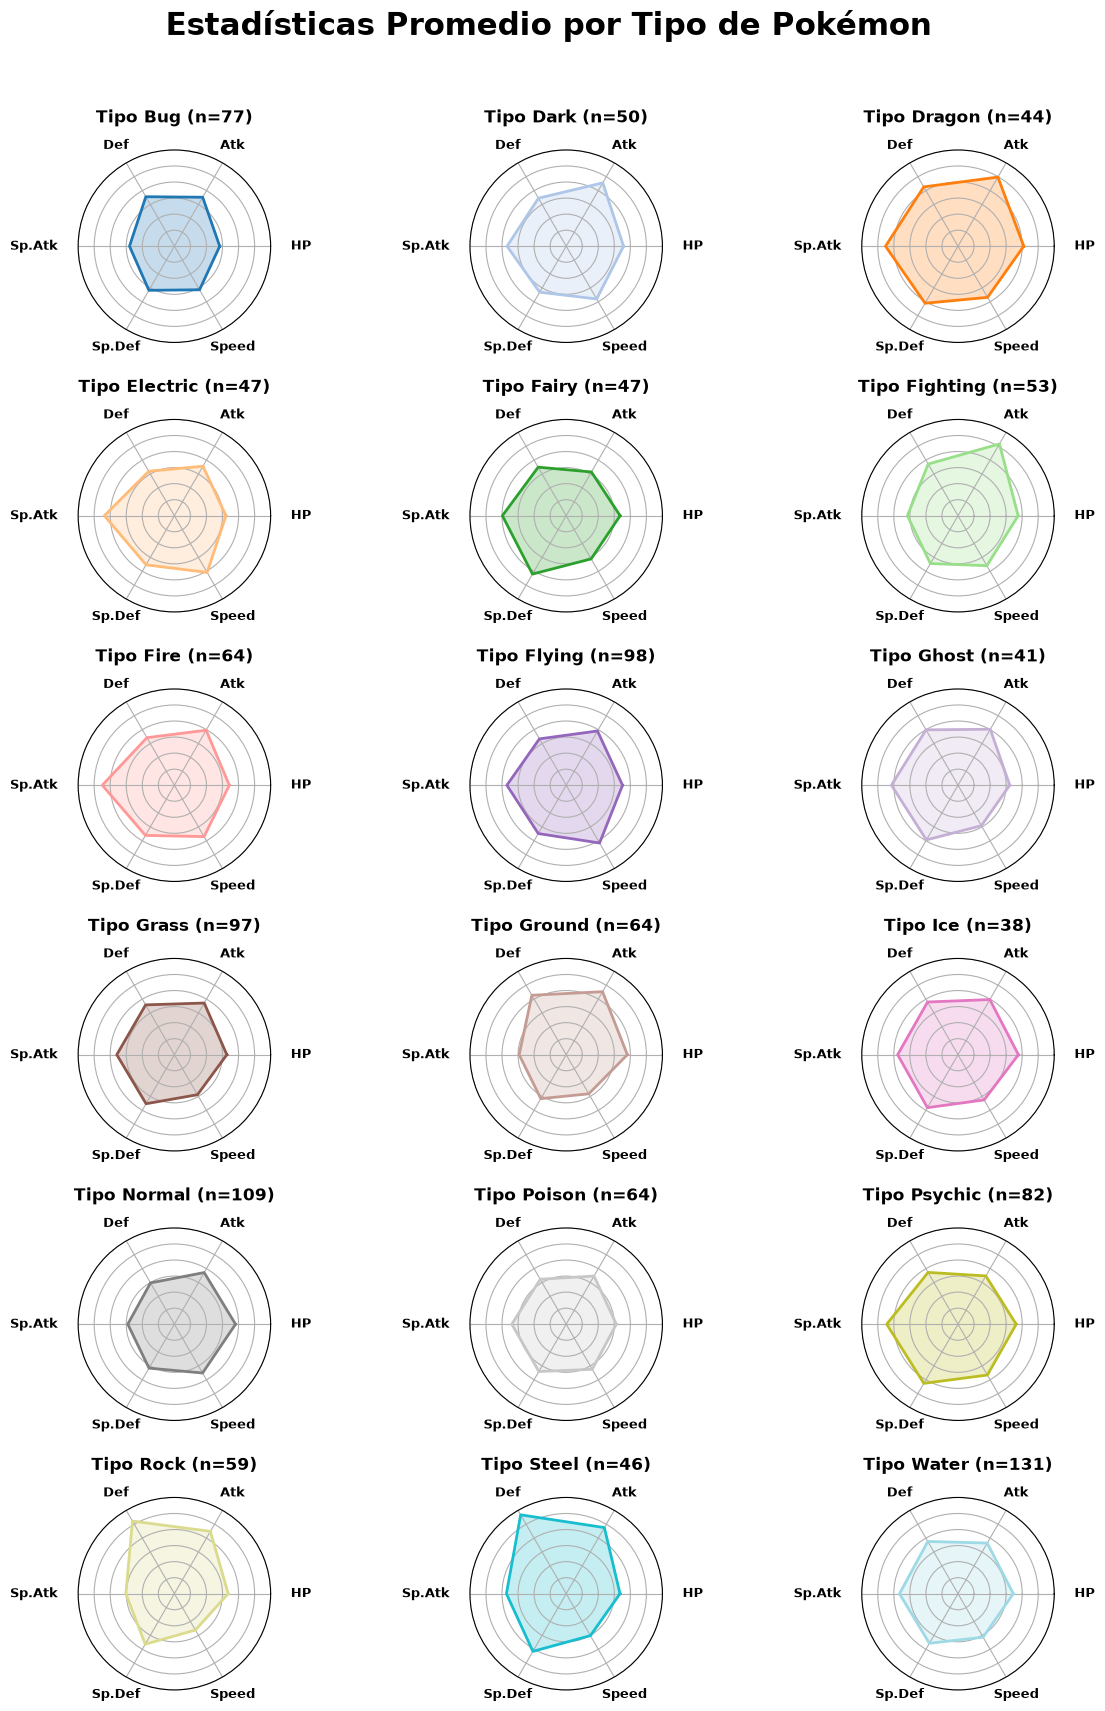

In [44]:
stats_cols = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
labels = ['HP', 'Atk', 'Def', 'Sp.Atk', 'Sp.Def', 'Speed']
num_vars = len(stats_cols)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  

unique_types = sorted(
    pd.concat([PokemonSet['type1'], PokemonSet['type2']]).dropna().unique()
)

color_map = plt.colormaps['tab20'].resampled(len(unique_types))

fig, axs = plt.subplots(
    nrows=6, 
    ncols=3, 
    figsize=(14, 20),  
    subplot_kw=dict(polar=True)
)

plt.subplots_adjust(wspace=0.3, hspace=0.4)

for i, (ax, pokemon_type) in enumerate(zip(axs.flat, unique_types)):
    
    mask = (PokemonSet['type1'] == pokemon_type) | (PokemonSet['type2'] == pokemon_type)
    type_df = PokemonSet[mask]
    count = len(type_df)
    
    if count > 0:
        values = type_df[stats_cols].mean().tolist()
        values += values[:1] 
    else:
        values = [0] * (num_vars + 1)

    color = color_map(i)
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9, fontweight='bold')

    ax.tick_params(axis='x', pad=4)

    for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
        if np.isclose(angle, np.pi):       
            label.set_horizontalalignment('right')
        elif np.isclose(angle, 0):         
            label.set_horizontalalignment('left')
    
    ax.set_ylim(0, 120) 
    ax.set_yticklabels([])

    ax.set_title(f'Tipo {pokemon_type.capitalize()} (n={count})', size=12, y=1.1, fontweight='bold')

fig.suptitle('Estadísticas Promedio por Tipo de Pokémon', size=22, y=0.95, fontweight='bold')
plt.savefig('RadarChart_Types.png')

plt.show()

In [45]:
Poder_Acero = Pokemones_Acero['base_total'].mean()
Poder_Agua = Pokemones_Agua['base_total'].mean()
Poder_Bicho = Pokemones_Bicho['base_total'].mean()
Poder_Dragon = Pokemones_Dragón['base_total'].mean()
Poder_Electrico = Pokemones_Eléctrico['base_total'].mean()
Poder_Fantasma = Pokemones_Fantasma['base_total'].mean()
Poder_Fuego = Pokemones_Fuego['base_total'].mean()
Poder_Hada = Pokemones_Hada['base_total'].mean()
Poder_Hielo = Pokemones_Hielo['base_total'].mean()
Poder_Lucha = Pokemones_Lucha['base_total'].mean()
Poder_Normal = Pokemones_Normal['base_total'].mean()
Poder_Planta = Pokemones_Planta['base_total'].mean()
Poder_Psiquico = Pokemones_Psíquico['base_total'].mean()
Poder_Roca = Pokemones_Roca['base_total'].mean()
Poder_Siniestro = Pokemones_Siniestro['base_total'].mean()
Poder_Tierra = Pokemones_Tierra['base_total'].mean()
Poder_Veneno = Pokemones_Veneno['base_total'].mean()
Poder_Volador = Pokemones_Volador['base_total'].mean()


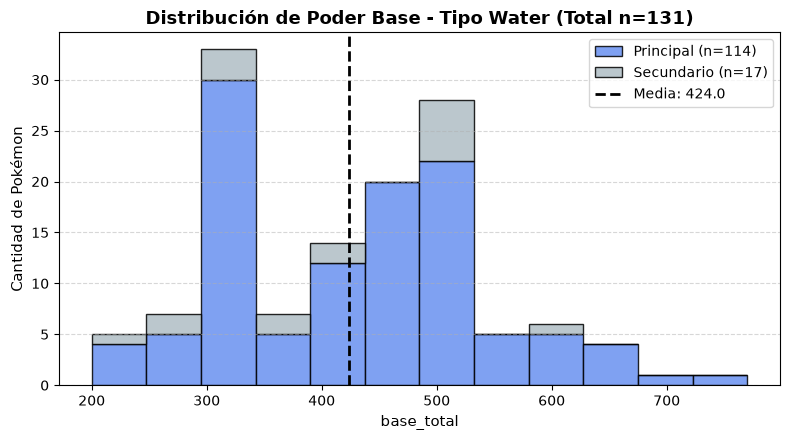

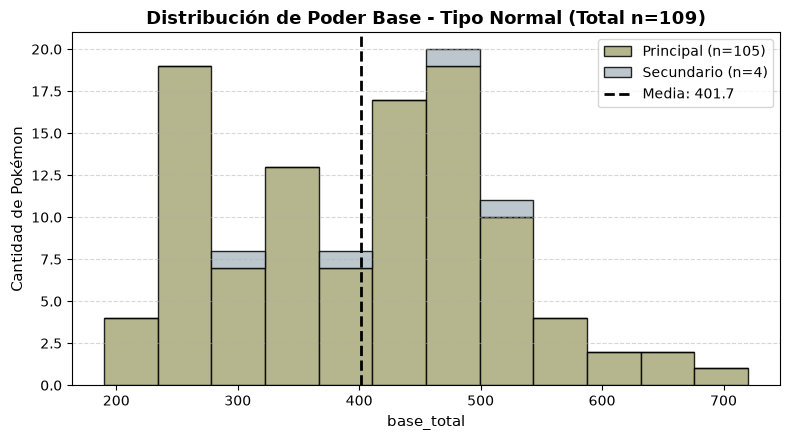

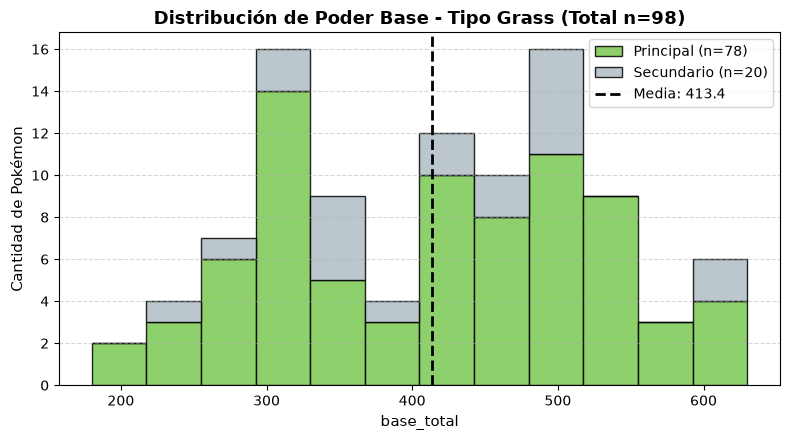

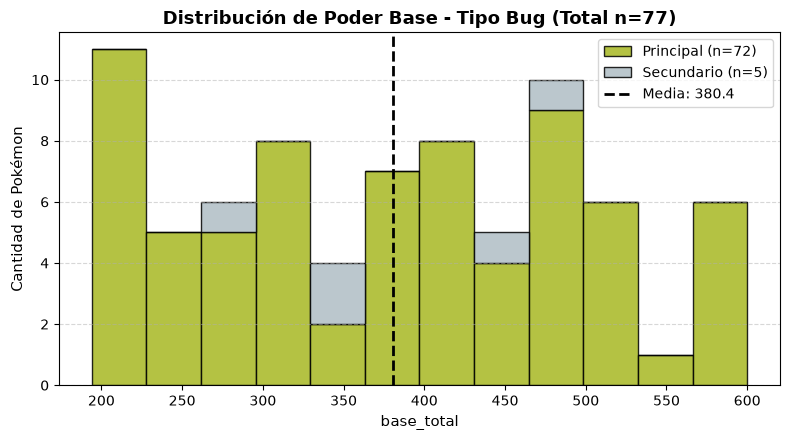

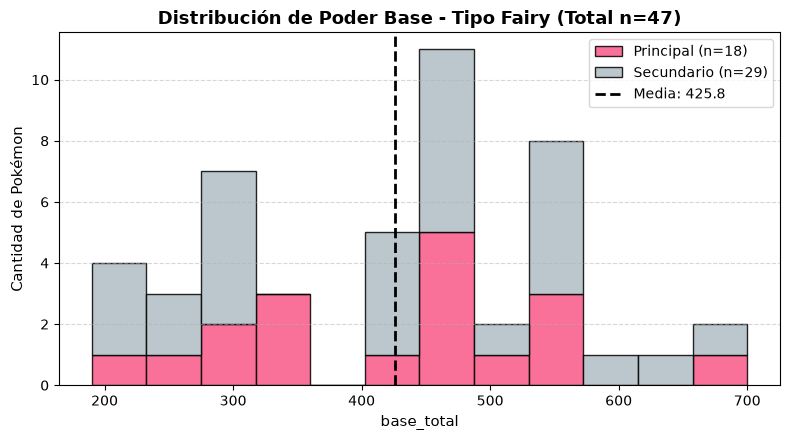

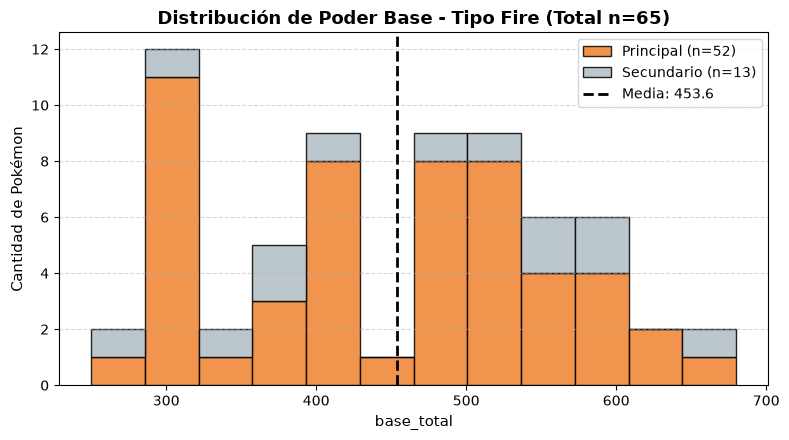

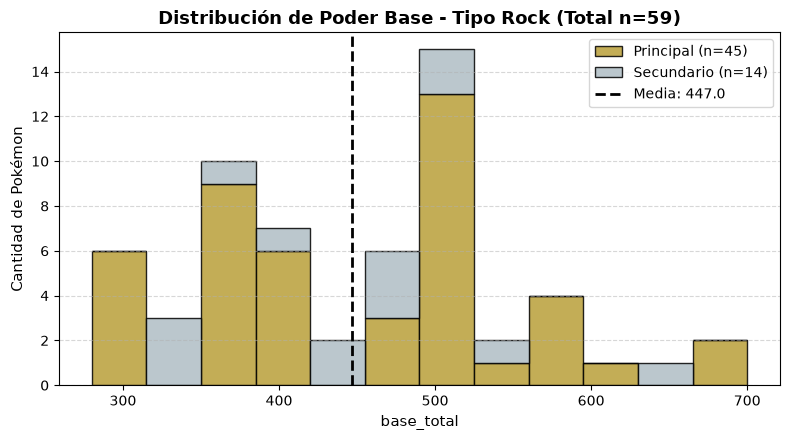

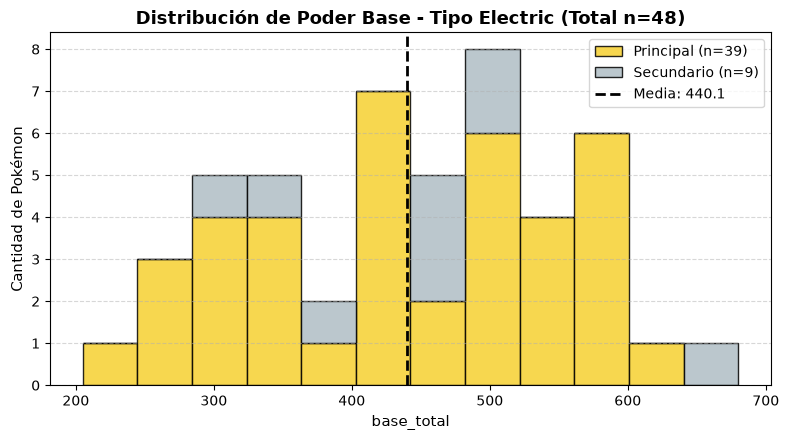

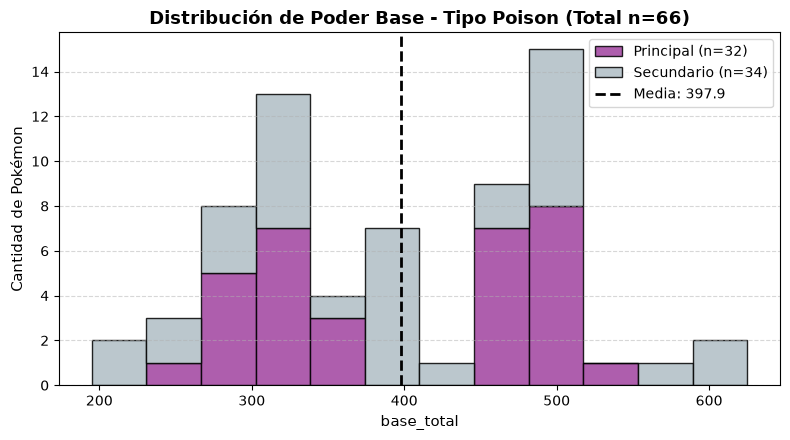

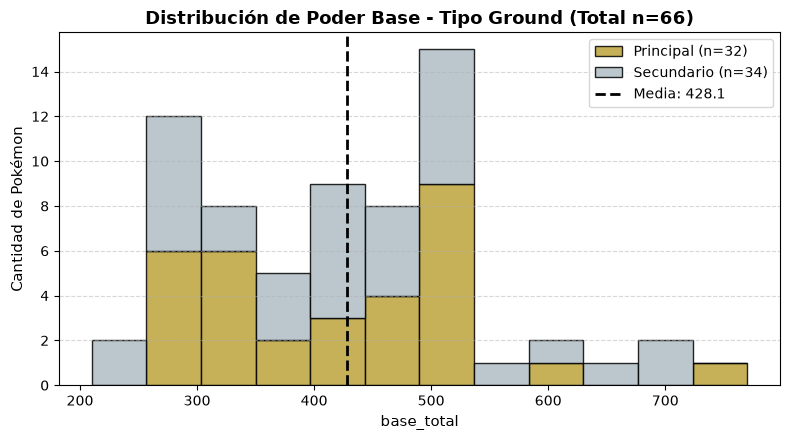

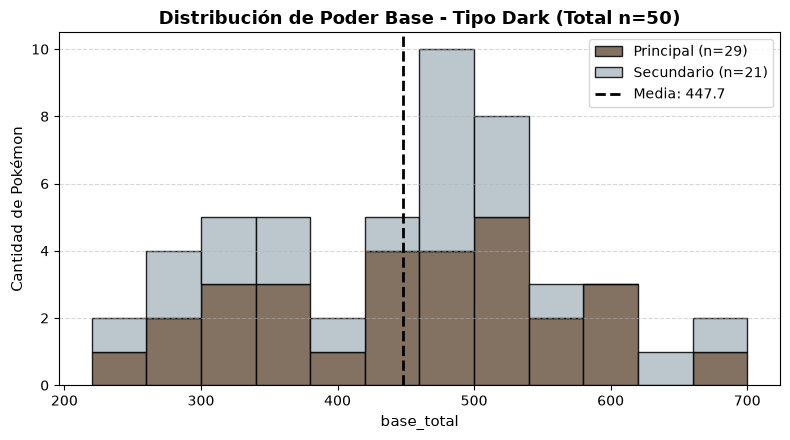

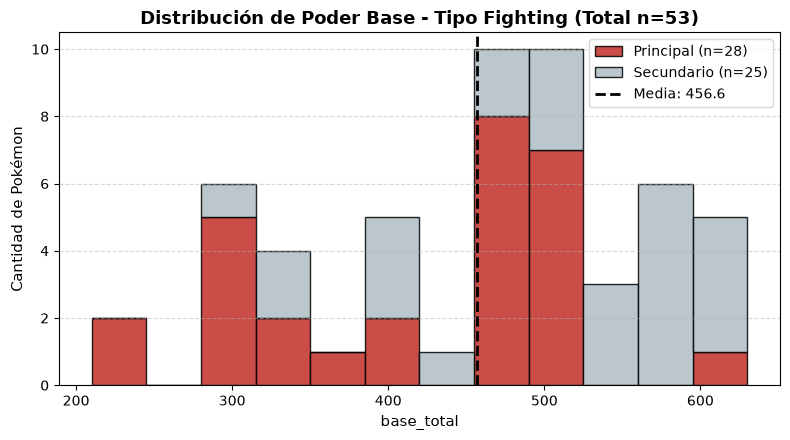

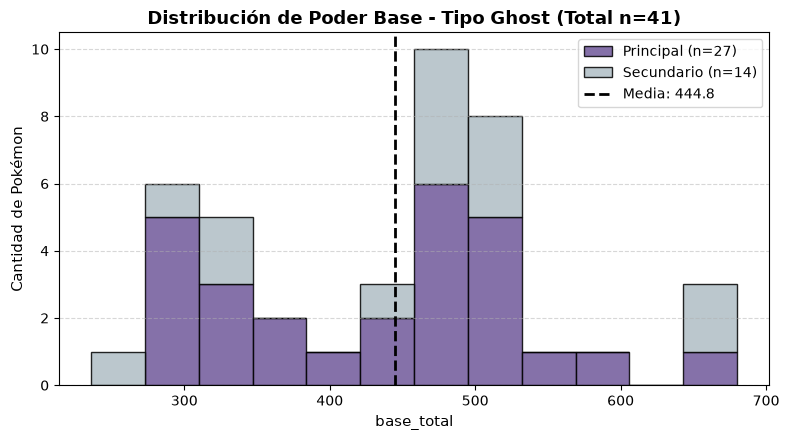

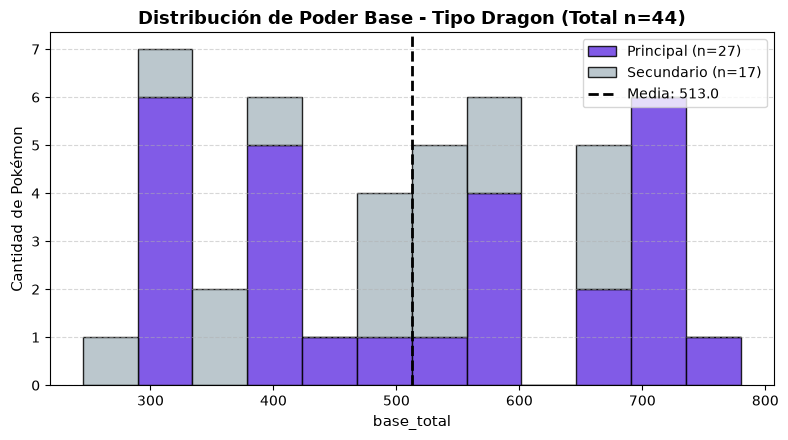

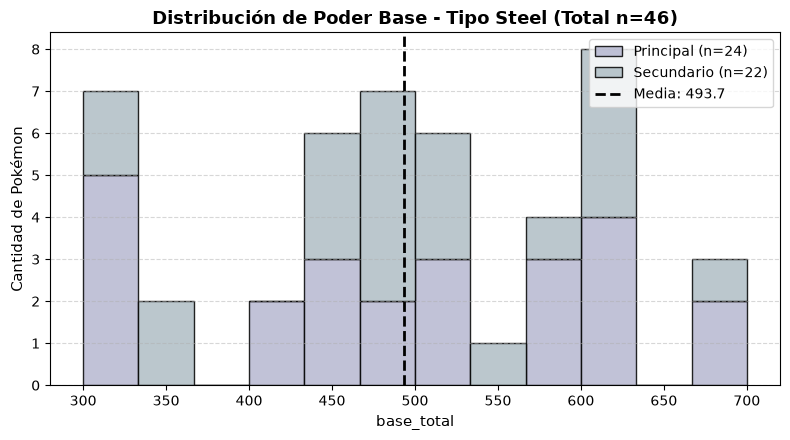

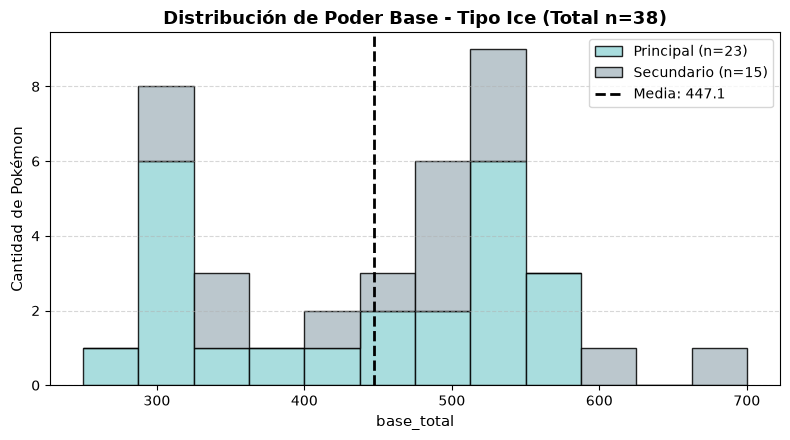

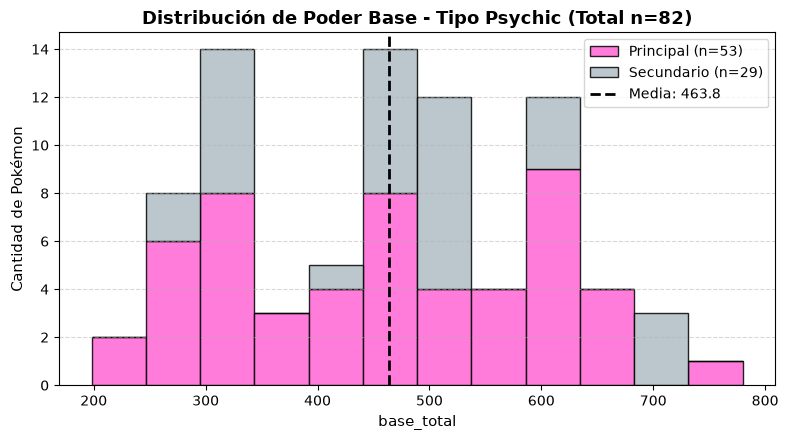

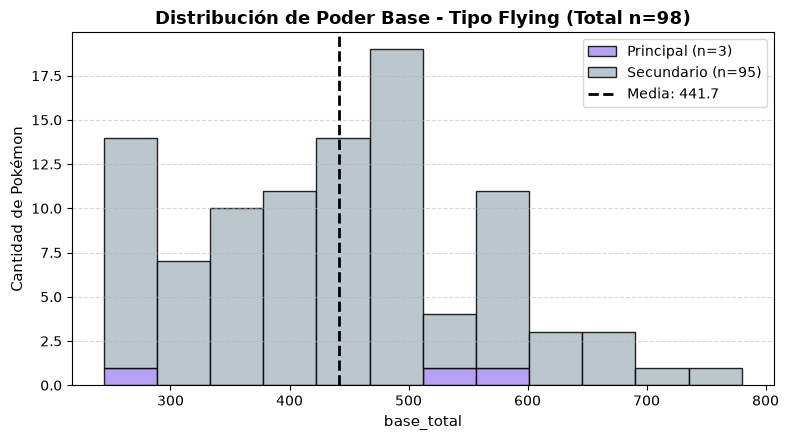

In [46]:
def graficar_distribucion_tipo(df, tipo, color_principal='orangered', color_secundario='#B0BEC5'):
    tipo_limpio = str(tipo).strip().lower()
    
    # Manejo seguro de NaN y espacios en blanco
    t1 = df['type1'].fillna('').astype(str).str.strip().str.lower()
    t2 = df['type2'].fillna('').astype(str).str.strip().str.lower()
    
    # Filtros
    sub_tipo1 = df[t1 == tipo_limpio]['base_total'].dropna()
    sub_tipo2 = df[t2 == tipo_limpio]['base_total'].dropna()
    
    total = len(sub_tipo1) + len(sub_tipo2)
    if total == 0:
        print(f"Aviso: No se encontraron registros para '{tipo}'")
        return

    # Si una de las dos series está vacía, evitamos que ax.hist falle con listas vacías
    datos = []
    colores = []
    etiquetas = []
    
    if len(sub_tipo1) > 0:
        datos.append(sub_tipo1)
        colores.append(color_principal)
        etiquetas.append(f'Principal (n={len(sub_tipo1)})')
        
    if len(sub_tipo2) > 0:
        datos.append(sub_tipo2)
        colores.append(color_secundario)
        etiquetas.append(f'Secundario (n={len(sub_tipo2)})')

    todos = pd.concat([sub_tipo1, sub_tipo2])
    mu = todos.mean()
    
    fig, ax = plt.subplots(figsize=(8, 4.5))
    
    ax.hist(
        datos,
        bins=12,
        stacked=True,
        color=colores,
        edgecolor='black',
        alpha=0.85,
        label=etiquetas
    )
    
    ax.axvline(mu, color='black', linestyle='--', linewidth=2, label=f'Media: {mu:.1f}')

    ax.set_title(f'Distribución de Poder Base - Tipo {tipo.capitalize()} (Total n={total})', fontsize=13, fontweight='bold')
    ax.set_xlabel('base_total', fontsize=11)
    ax.set_ylabel('Cantidad de Pokémon', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(frameon=True, loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Ejecución
for tipo, hex_color in colores_tipos.items():
    graficar_distribucion_tipo(PokemonSet, tipo, color_principal=hex_color)

En base a los gráficos de cada tipo, se ve que el tipo de pokemon no influye directamente en el poder total de los pokemones, pues como se observa la distribución de poder en cada tipo es bastante dispersa y la media nisiquiera se encuentra ubicada en el rango de mayor frecuencia para la mayoría de los casos (no hay una distribución normal). Sin embargo, de los gráficos de radar se ve que el tipo del pokemon si define estadísticas específicas generales para estos. Por ejemplo, el tipo Roca y Acero poseen defensas mucho más altas que el resto, el tipo lucha posee un mayor ataque, los tipos agua, veneno, hielo, planta y bicho tienen estadísticas más equilibradas, y el tipo dragón tiene notoriamente estadísticas más altas al promedio en cada una de ellas.

Por lo tanto, el tipo de pokemon no les define un poder total específico, pero si les da un promedio base total distinto y un promedio más alto o más bajo para algunas características que definen a su tipo.

# Felicidad base de los Pokemones

La felicidad base de los pokemones es una característica única, pues a primera vista pareciera ser más una característica cualitativa que cuantitativa (¿Es este pokemon feliz o no?).
En el videojuego se suele separar esta característica en 3 grupos:
- Desconfiados (0-35)
- Normales (35-70)
- Amigables (>70)

Donde la felicidad base normalmente alcanza un máximo de 140. Ahora, la felicidad base es una característica propia de los pokemones, pero la felicidad como tal puede modificarse al compartir con este, y alcanzar hasta un valor máximo de 255. Por más abstracto que parezca esta característica, es en realidad una muy importante, pues la felicidad de un pokemon influye directamente en su poder y también en su capacidad para evolucionar (muchos pokemones requieren una felicidad mínima para poder evolucionar, lo que hace importante el relacionarte con ellos para potenciarlos).

In [47]:
PokemonSet['capture_rate'] = pd.to_numeric(PokemonSet['capture_rate'])
PokemonHapCap = PokemonSet.dropna(subset=['base_happiness', 'capture_rate', 'type1', 'base_total'])

ValueError: Unable to parse string "30 (Meteorite)255 (Core)" at position 773

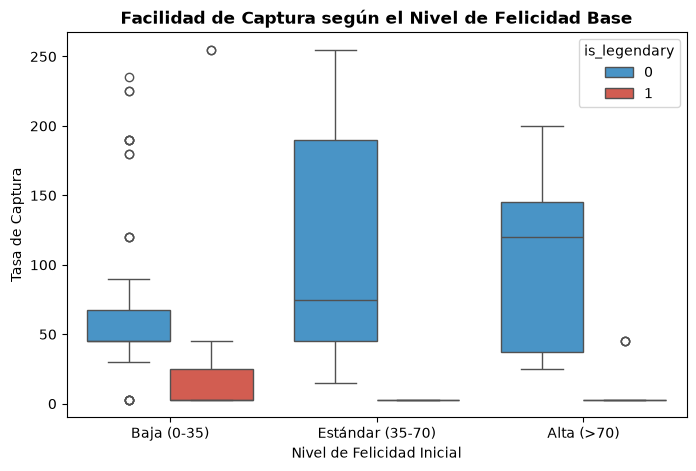

In [ ]:
bins = [-1, 35, 70, 150]
labels = ['Baja (0-35)', 'Estándar (35-70)', 'Alta (>70)']
PokemonHapCap['rango_felicidad'] = pd.cut(PokemonHapCap['base_happiness'], bins=bins, labels=labels)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=PokemonHapCap,
    x='rango_felicidad',
    y='capture_rate',
    hue='is_legendary',                      # Subdivide cada rango por esta columna
    palette={0: '#3498db', 1: '#e74c3c'},
    color='steelblue'
)
plt.title('Facilidad de Captura según el Nivel de Felicidad Base', fontweight='bold')
plt.xlabel('Nivel de Felicidad Inicial')
plt.ylabel('Tasa de Captura')
plt.show()

! Este resultado me sorprende, pues esperaba que la relación entre tasa de captura y la felicidad base fuera directamente proporcional (mientras mayor felidad, más fácil capturar).

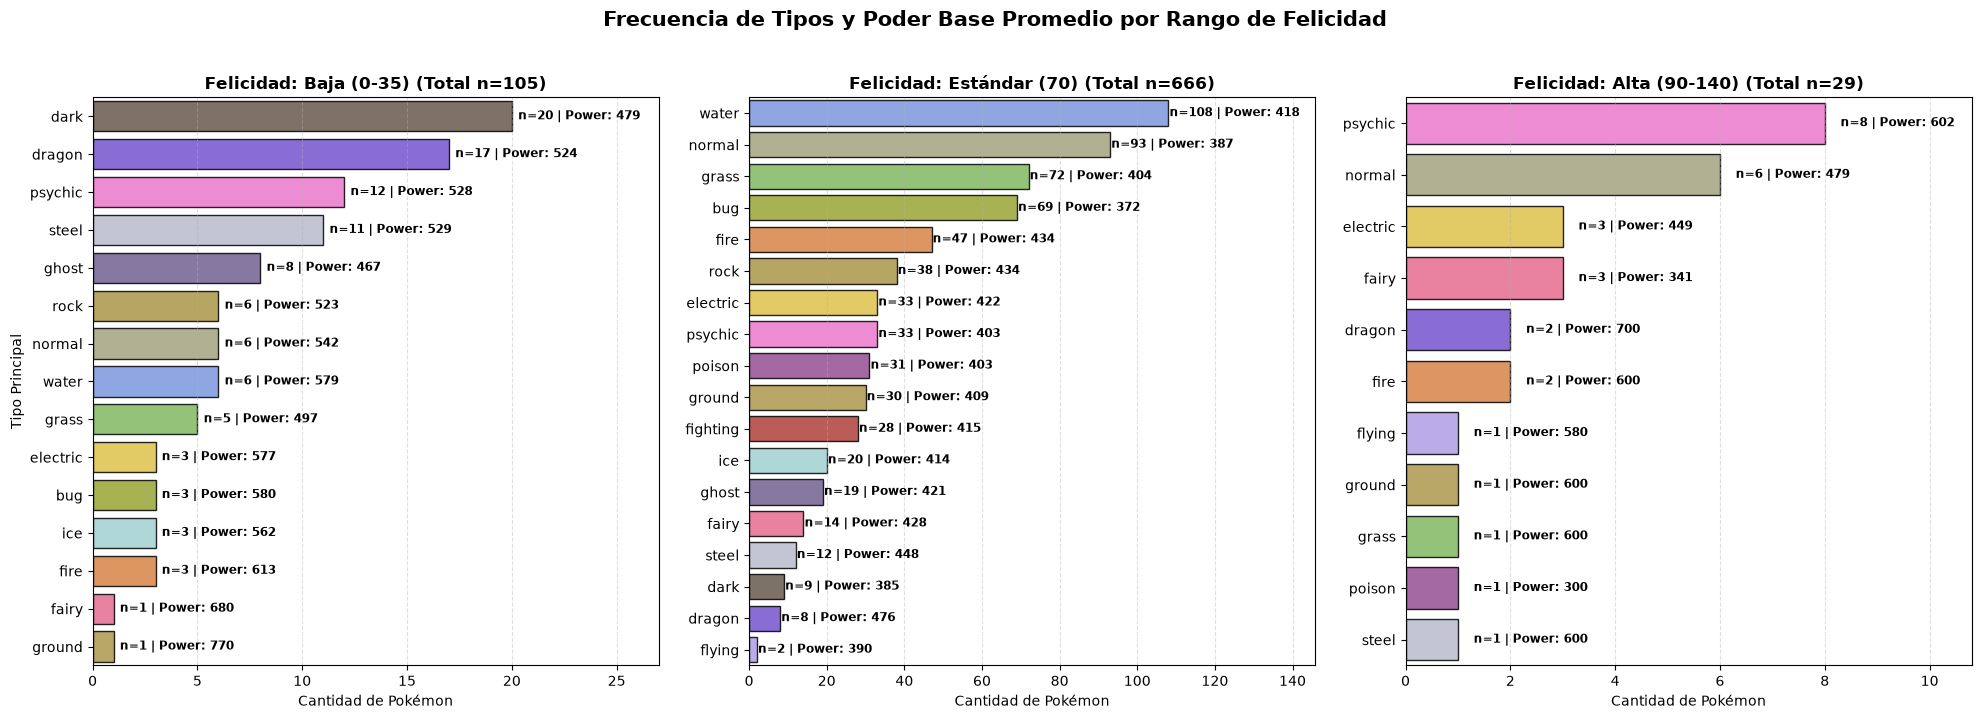

In [ ]:
PokemonHapCap['type1'] = PokemonHapCap['type1'].str.lower()

bins = [-1, 35, 70, 140]
labels = ['Baja (0-35)', 'Estándar (70)', 'Alta (90-140)']
PokemonHapCap['rango_felicidad'] = pd.cut(
    PokemonHapCap['base_happiness'], 
    bins=bins, 
    labels=labels
)

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=False)

for ax, rango in zip(axes, labels):
    subset = PokemonHapCap[PokemonHapCap['rango_felicidad'] == rango]
    
    if subset.empty:
        ax.set_title(f'Felicidad {rango} (Sin datos)')
        continue
    
    resumen = (
        subset.groupby('type1')['base_total']
        .agg(cantidad='count', poder_promedio='mean')
        .sort_values(by='cantidad', ascending=False)
    )
    
    colores_barra = [colores_tipos.get(t, '#B0BEC5') for t in resumen.index]
    
    sns.barplot(
        x=resumen['cantidad'],
        y=resumen.index,
        palette=colores_barra,
        hue=resumen.index,
        legend=False,
        edgecolor='black',
        alpha=0.85,
        ax=ax
    )
    
    for barra, (_, row) in zip(ax.patches, resumen.iterrows()):
        ancho = barra.get_width()
        if ancho > 0:
            ax.text(
                ancho + 0.3,
                barra.get_y() + barra.get_height() / 2,
                f"n={int(row['cantidad'])} | Power: {row['poder_promedio']:.0f}",
                va='center',
                fontsize=8.5,
                fontweight='semibold'
            )
            
    ax.set_title(f'Felicidad: {rango} (Total n={len(subset)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Cantidad de Pokémon', fontsize=10)
    ax.set_ylabel('Tipo Principal' if ax == axes[0] else '', fontsize=10)
    
    ax.set_xlim(0, resumen['cantidad'].max() * 1.35)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Frecuencia de Tipos y Poder Base Promedio por Rango de Felicidad', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

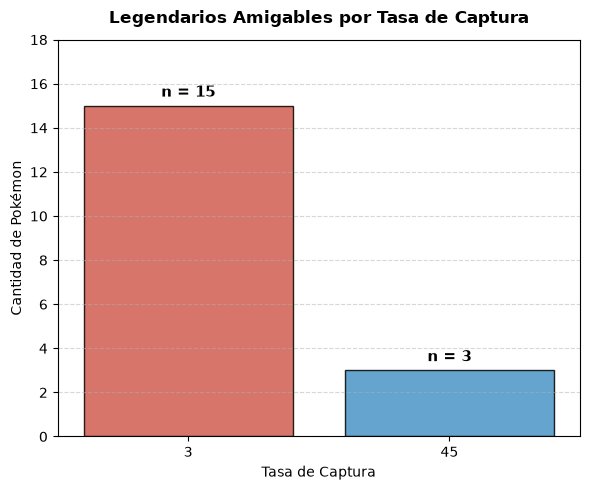

In [ ]:
amigables = PokemonHapCap[PokemonHapCap['base_happiness'] > 70].copy()

columnas = ['name', 'type1', 'base_happiness', 'base_total', 'is_legendary', 'capture_rate']

LegendariosHapHigh = (
    amigables[amigables['is_legendary'] == 1][columnas]
    .sort_values(by=['type1', 'name'])
    .reset_index(drop=True)
)

LegendariosHapHigh['capture_rate'] = LegendariosHapHigh['capture_rate'].astype(int).astype(str)

plt.figure(figsize=(6, 5))
ax = sns.countplot(
    data=LegendariosHapHigh,
    x='capture_rate',
    hue='capture_rate',
    order=['3', '45'],
    palette=['#e74c3c', '#3498db'],
    legend=False,
    edgecolor='black',
    alpha=0.85
)

for p in ax.patches:
    altura = int(p.get_height())
    ax.annotate(
        f'n = {altura}',
        (p.get_x() + p.get_width() / 2., altura),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        xytext=(0, 4),
        textcoords='offset points'
    )

ax.set_title('Legendarios Amigables por Tasa de Captura', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Tasa de Captura', fontsize=10)
ax.set_ylabel('Cantidad de Pokémon', fontsize=10)
ax.set_ylim(0, LegendariosHapHigh['capture_rate'].value_counts().max() + 3)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
NormalesHapHigh = (
    amigables[amigables['is_legendary'] == 0][columnas]
    .sort_values(by=['type1', 'name'])
    .reset_index(drop=True)
)

NormalesHapHigh

,name,type1,base_happiness,base_total,is_legendary,capture_rate
0,Luxio,electric,100,363,0,120.0
1,Pachirisu,electric,100,405,0,200.0
2,Clefable,fairy,140,483,0,25.0
3,Clefairy,fairy,140,323,0,150.0
4,Cleffa,fairy,140,218,0,150.0
5,Ambipom,normal,100,482,0,45.0
6,Blissey,normal,140,540,0,30.0
7,Chansey,normal,140,450,0,30.0
8,Happiny,normal,140,220,0,130.0
9,Lopunny,normal,140,580,0,60.0


C:\Users\benja\AppData\Local\Temp\ipykernel_19588\2274390580.py:14: UserWarning: 
The palette list has fewer values (2) than needed (6) and will cycle, which may produce an uninterpretable plot.
  ax = sns.countplot(


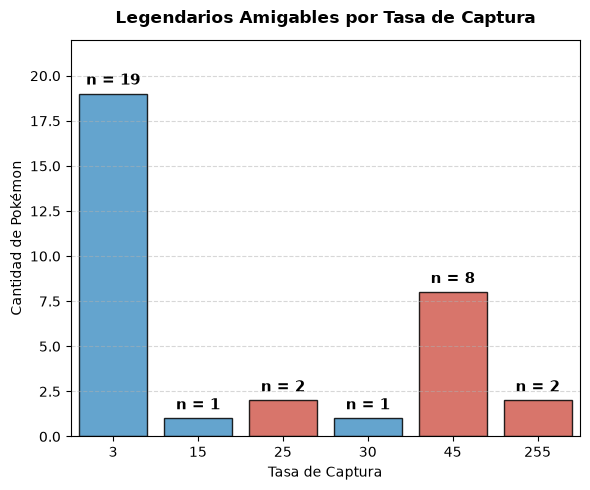

In [ ]:
amargados = PokemonHapCap[PokemonHapCap['base_happiness'] < 35].copy()

columnas = ['name', 'type1', 'base_happiness', 'base_total', 'is_legendary', 'capture_rate']

LegendariosHapLow = (
    amargados[amargados['is_legendary'] == 1][columnas]
    .sort_values(by=['type1', 'name'])
    .reset_index(drop=True)
)

LegendariosHapLow['capture_rate'] = LegendariosHapLow['capture_rate'].astype(int).astype(str)

plt.figure(figsize=(6, 5))
ax = sns.countplot(
    data=LegendariosHapLow,
    x='capture_rate',
    hue='capture_rate',
    order=['3', '15', '25', '30', '45', '255'],
    palette=['#e74c3c', '#3498db'],
    legend=False,
    edgecolor='black',
    alpha=0.85
)

for p in ax.patches:
    altura = int(p.get_height())
    ax.annotate(
        f'n = {altura}',
        (p.get_x() + p.get_width() / 2., altura),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        xytext=(0, 4),
        textcoords='offset points'
    )

ax.set_title('Legendarios Amigables por Tasa de Captura', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Tasa de Captura', fontsize=10)
ax.set_ylabel('Cantidad de Pokémon', fontsize=10)
ax.set_ylim(0, LegendariosHapLow['capture_rate'].value_counts().max() + 3)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
LegendariosHapLow

,name,type1,base_happiness,base_total,is_legendary,capture_rate
0,Buzzwole,bug,0,570,1,25
1,Genesect,bug,0,600,1,3
2,Pheromosa,bug,0,570,1,255
3,Darkrai,dark,0,600,1,3
4,Guzzlord,dark,0,570,1,15
5,Yveltal,dark,0,680,1,45
6,Kyurem,dragon,0,700,1,3
7,Rayquaza,dragon,0,780,1,45
8,Reshiram,dragon,0,680,1,3
9,Zekrom,dragon,0,680,1,3


In [ ]:
UnhappyPokemon = PokemonHapCap[PokemonHapCap['base_happiness'] == 0]
print(len(UnhappyPokemon))

36


In [ ]:
LegendariosHapNormal = PokemonHapCap[(PokemonHapCap['base_happiness'] > 35) & (PokemonHapCap['base_happiness'] < 70)]
print(f' En el grupo de felicidad baja hay {len(LegendariosHapLow)} pokemones')
print(f' En el grupo de felicidad alta hay {len(LegendariosHapHigh)} pokemones')
print(f' En el grupo de felicidad normal hay {len(LegendariosHapNormal)} pokemones')

 En el grupo de felicidad baja hay 36 pokemones
 En el grupo de felicidad alta hay 29 pokemones
 En el grupo de felicidad normal hay 0 pokemones


Mi mayor sorpresa de este análisis fue que al parecer la felicidad y la tasa de captura no están relacionadas entre sí (osea sí, pero esperen la explicación). 

La mayor parte de los pokemones tienen una felicidad base normal, además de una tasa de captura alta (o decente, en comparación al resto). Esto es general para la gran mayoría de los pokemones (no legendarios), pues los grupos de felicidad base baja y alta son mucho más pequeños. Se determina que estos grupos extremos no siguen un orden cuantitativo para ordenarse de esta forma, sino que más bien su felicidad base depende de su historia y características que los definen.

Por un lado tenemos el grupo de felicidad base baja. El tipo de pokemon que más destaca en este grupo son los tipo siniestros (dark), lo cual es esperable debido a sus personalidades sombrías. También contamos con la mayor parte de pokemones legendarios en este grupo, donde 